# Komlós Conjecture — ShinkaEvolve Launcher

**Task**: Find an n×n matrix A of unit-column-norm vectors that maximises the minimum discrepancy  
$$\min_{x \in \{-1,+1\}^n} \|Ax\|_\infty$$
**Objective**: higher discrepancy = harder instance for the Komlós conjecture (n=9 for evaluation)

The code in this notebook is split into **five sections**.

1.  A pre-flight check that verifies **ShinkaEvolve imports properly**, and that an **OpenRouter API key** is present in your project.

2.  Configures a ShinkaEvolve experiment for the Komlos lower bound problem

3.  Launches the ShinkaEvolve experiment using `ShinkaEvolveRunner`

4.  Visualizes the experiment's evolution using the WebUI through `shinka_visualize`.

Before beginning **make sure you have the following**

- If you are using Jupyterlab to edit this notebook in your web browser, make sure you've started your Jupyter server in the virtual environment

- If you are editing this notebook in VSCode, make sure to select the Python kernel associated with the environment that you've created. It should say `tutorial_shinka (<version>)` with a Python executable located at `.venv/bin/python`.

- You can more-detailed instructions on how to do this in `recipes/shinka_via_jupyter.md`

# Part 1. Pre-flight Check

Before we begin, let's verify that our programming environment is set up correctly. This notebook should be running via a JupyterLab server executed in a virtual environment. The following block of code will do two things.

1.  Check that your virtual environment has the Python ShinkaEvolve package `shinka` installed.

2.  Load the **OpenRouter API key** into the Jupyter notebook.

**Important (!)** - Make sure that your OpenRouter API key is contained a `.env` file located at the root of this project, i.e. immediately inside the `tutorial_shinka/` directory.

In [1]:
import warnings
import dotenv
import os

# Suppress third-party warnings before importing shinka
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

# Check if ShinkaEvolve is importable
try:
    import shinka
except ImportError:
    print("shinka not found, make sure to open this notebook with the ShinkaEvolve environment active")

# Find the .env file
env_path = dotenv.find_dotenv()

# Make sure that there's a .env file
assert env_path, ".env not found, please add it to the root of this project."

# Find the repository root assuming that's where the .env file is
repo_path = os.path.dirname(env_path)
activate_path = os.path.join(repo_path, '.venv/bin/activate')

# Print out where the .env file and repo root are
print("> loaded .env from {}".format(env_path))
print("> repo root located at {}".format(repo_path))

# Load the environment variables
dotenv.load_dotenv()

# Check that OPENROUTER_API_KEY is set in the .env file
if os.environ.get("OPENROUTER_API_KEY"):
    print("> OPENROUTER_API_KEY found")
else:
    print("> WARNING: OPENROUTER_API_KEY not set — add it to .env file")

> loaded .env from /Users/mp2557/Documents/Research/tutorial_shinka/.env
> repo root located at /Users/mp2557/Documents/Research/tutorial_shinka
> OPENROUTER_API_KEY found


We can verify that `evaluate.py` runs correctly on `initial_program.py` before launching evolution.

In [2]:
import evaluate
import initial_program

# ── Evaluation parameters (forwarded to evaluate.py via environment variables) ──
n = 9            # instance size: matrix will be n×n

# Test the initial program for Komlós
output = initial_program.run_komlos(n=n)

# Check if the program outputs a valid result
valid, msg = evaluate.validate_fn(output)

# Assert check
assert valid, f"Smoke test failed: {msg}"
_, cost, _ = output
print(f"Smoke test: PASSED  (n={n}, min_discrepancy={cost:.6f})")

Smoke test: PASSED  (n=9, min_discrepancy=0.771189)


We're ready to go!

# Part 2. Configuring the ShinkaEvolve Experiment

This section expands upon the one in the `circle_packing` experiment folder in a few ways. First, we modify the following parameters of the `evaluate.py`:
- Our task requires a keyword argument `n` that we set equal to $9$, which constrols the dimension of the matrices we are using to test the Komlos conjecture. The hope of using ShinkaEvolve for a task like this one is to play with this parameter and see if there is a pattern in the extremal matrices found, which can ideally by generalized to a proof.
- We evaluate the candidate programs `num_runs = 6` times instead of just once, and keep the best one. This makes a difference if the programs generated by the LLMs use randomness, but they most likely are given the task and the prompt.
- Since those runs are independent, we run them in parallel using `num_workers = 3` cores.

Instead of hard-coding these in the `evalute.py` file, we set them as environment variables (e.g. ``) in this notebook, to make them easier to modify.

We are also going to modify a concurrency parameter in the `ShinkaEvolveRunner`:
- We are also going to run multiple mutations in parallel, by setting `max_evaluation_jobs = 2`. This means that at any given time we could have as many as `max_evaluation_jobs x num_workers = 6` cores working, and potentially more if the program themselves use parallelism. 

In [3]:
import datetime as dt
from shinka.core import ShinkaEvolveRunner, EvolutionConfig
from shinka.database import DatabaseConfig
from shinka.launch import LocalJobConfig

# Path to the initial program
INIT_PROGRAM_PATH = "initial_program.py"

# Path to evaluate.py
EVAL_PROGRAM_PATH = "evaluate.py"

# ── Evaluation parameters (forwarded to evaluate.py via environment variables) ──
n = 9            # instance size: matrix will be n×n
NUM_RUNS = 6     # evaluation runs per candidate
NUM_WORKERS = 3  # parallel workers for evaluation runs

os.environ["N"] = str(n)
os.environ["NUM_RUNS"] = str(NUM_RUNS)
os.environ["NUM_WORKERS"] = str(NUM_WORKERS)

# A description of the task ShinkaEvolve is solving to be sent as an LLM prompt.
TASK_SYS_MSG = """
You are an expert mathematician specializing in discrepancy theory and linear algebra.

You want to construct hard instances for the Komlos conjecture by generating Python code. In other words, you want to find a matrix A of size n x n such that
the minimum discrepancy of its columns (i.e. the largest entry of the vector Ax - in absolute value - is minimized) is as large as possible.

Key directions to explore:
1. Try looking for matrices with explicit structure that prevents cancellations of columns
2. Try different structured matrices (Hadamard, conference, Toeplitz, etc.)  as starting blocks for the exploration.
3. You can use the scipy package to find vectors with larger discrepancy (e.g. Nelder-Mead, L-BFGS, etc. )
4. You can use other optimization heuristics such as simulated annealing or evolutionary algorithms in your program, and you can combine different heuristics
5. Looking for structured explicit constructions and use that as a starting point for the optimization heuristics could be very useful

Constraints:
- construct_vectors(n) must return a matrix of size n x n.
- run_komlos(n) (the fixed interface) calls construct_vectors(n) and returns (vectors, cost, signs).
- HIGHER discrepancy = BETTER score.

Be creative and try to find a new solution better than the best known result. I believe in your ability and I am excited to see what you can do."""

# Number of generations to run in this experiment
NUM_GENERATIONS = 30

# Results will be stored in a directory "circpack_<CURRENT DATE-TIME>"
experiment_name = "komlos_" + dt.datetime.now().strftime("%Y%m%d_%H%M%S")

# Set RESULTS_DIR
RESULTS_DIR = "results/{}".format(experiment_name)

# Print out the path
print(f"> Results dir: {RESULTS_DIR}")

# Set cost if you want to try this out!
cost = 2

# Define the MAX_API_COST variable
MAX_API_COST = cost or None

# Has my cost been set?
print('> Cost limit? {}'.format(MAX_API_COST))

# Define all LLM related hyperparameters.
LLM_MODELS = [
    "openrouter/anthropic/claude-haiku-4-5",
    "openrouter/openai/gpt-5.4-mini"
    "openrouter/openai/gpt-5.2-codex",
    "openrouter/openai/o4-mini",
    "openrouter/openai/gpt-5-nano",
    "openrouter/google/gemini-3.1-flash-lite-preview"
]

META_LLM_MODELS = ["openrouter/openai/o4-mini"]

NOVELTY_LLM_MODELS = ["openrouter/openai/o4-mini"]

EMBEDDING_MODEL = "openrouter/openai/text-embedding-3-small"


# Number of "islands" to preserve diversity instead of promoting early advances too much 

NUM_ISLANDS = 3

###

# Set the evolution config object
evo_config = EvolutionConfig(init_program_path=INIT_PROGRAM_PATH,
                             task_sys_msg=TASK_SYS_MSG,
                             num_generations=NUM_GENERATIONS,
                             results_dir=RESULTS_DIR,
                             max_api_costs=MAX_API_COST,
                             llm_models=LLM_MODELS,
                             meta_llm_models=META_LLM_MODELS,
                             novelty_llm_models=NOVELTY_LLM_MODELS,
                             embedding_model=EMBEDDING_MODEL)


# Set the job config. ACTIVATE_SCRIPT is a parameter which tells what virtual
# environment ShinkaEvolve will run evolved programs in.
job_config = LocalJobConfig(eval_program_path=EVAL_PROGRAM_PATH,
                            activate_script=activate_path)

# If you're using Conda to manage your virtual environment, you will need to
# instead set CONDA_ENV. Uncomment this line to do that
# job_config = LocalJobConfig(eval_program_path=EVAL_PROGRAM_PATH,
#                             conda_env="shinka_ai4sd26")

# Number of islands is a hyperparameter which affects the evolution algorithm
# run by ShinkaEvolve. This also affects the visualization. See the guide
# at `recipes/hyperparameters.md` for more information.
db_config = DatabaseConfig(num_islands=NUM_ISLANDS)

> Results dir: results/komlos_20260422_124551
> Cost limit? 2


# Part 3. Launch ShinkaEvolve

Now we're ready to launch ShinkaEvolve. Pass all config parameters (the `EvolutionConfig, DatabaseConfig, LocalJobConfig` objects) to a `ShinkaEvolveRunner` object. Then call `run_async` to start the evolving.

**IMPORTANT (!)** - Running the next block will output a lot of text! You can continue on to **Part 4** as this block runs. **Part 5** will need to wait until this block finishes.

In [4]:
from time import perf_counter

MAX_PROPOSAL_JOBS = 3
MAX_EVALUATION_JOBS = 2

runner = ShinkaEvolveRunner(
    evo_config=evo_config,
    job_config=job_config,
    db_config=db_config,
    max_proposal_jobs=MAX_PROPOSAL_JOBS,
    max_evaluation_jobs=MAX_EVALUATION_JOBS,
    verbose=True,
)

tic = perf_counter()
await runner.run_async()
toc = perf_counter()

print(f"Evolution completed in {toc - tic:.1f} s")
print(f"Results saved to: {runner.results_dir}")

  @@@@@@@@@@@@@@@@@@@@@      ░██████╗██╗░░██╗██╗███╗░░██╗██╗░░██╗░█████╗░
  @                   @      ██╔════╝██║░░██║██║████╗░██║██║░██╔╝██╔══██╗
  @          @        @      ╚█████╗░███████║██║██╔██╗██║█████═╝░███████║
  @    @@   @@  @@    @      ░╚═══██╗██╔══██║██║██║╚████║██╔═██╗░██╔══██║
  @   @     @    @@   @      ██████╔╝██║░░██║██║██║░╚███║██║░╚██╗██║░░██║
  @    @@  @    @     @      ╚═════╝░╚═╝░░╚═╝╚═╝╚═╝░░╚══╝╚═╝░░╚═╝╚═╝░░╚═╝
  @        @          @      @@@@@@@@@@@@@@@
  @                   @   @@                 @@@@@
  @@@@@@@@@@@@@@@@@@@@ @@                       @  @@                 █▀▀
                      @                          @@  @                ██▄
                    @      @@                      @  @@
                   @       @         @              @   @             █░█
                   @                 @               @  @             ▀▄▀
                     @@@@@          @     @           @  @
                      @            @          @ 

2026-04-22 12:45:54 - shinka.core.async_runner - INFO - 🖥️  System resources detected:

2026-04-22 12:45:54 - shinka.core.async_runner - INFO -    • CPU cores: 8

2026-04-22 12:45:54 - shinka.core.async_runner - INFO -    • Memory: 16.0 GB

2026-04-22 12:45:54 - shinka.core.async_runner - INFO - 🔧 Concurrency settings:

...

2026-04-22 12:54:29 - backoff - INFO - Backing off query_openai_async(...) for 12.1s (openai.BadRequestError: Error
code: 400 - {'error': {'message': 'openai/gpt-5.4-miniopenrouter/openai/gpt-5.2-codex is not a valid model ID',    
'code': 400}, 'user_id': 'org_38Zu1WwDMaglMdangLcNGADoewQ'})

2026-04-22 12:54:29 - shinka.llm.providers.openai - WARNING - OpenAI - Retry 7 due to error: Error code: 400 -     
{'error': {'message': 'openai/gpt-5.4-miniopenrouter/openai/gpt-5.2-codex is not a valid model ID', 'code': 400},  
'user_id': 'org_38Zu1WwDMaglMdangLcNGADoewQ'}. Waiting 12.1s...

2026-04-22 12:54:29 - shinka.database.async_dbase - INFO - 🔧 Closing async database with monitoring...

2026-04-22 12:54:29 - shinka.database.async_dbase - INFO - Async database closed

CancelledError: 

# Part 4. Visualizing ShinkaEvolve using the WebUI

By default, logging information when running ShinkaEvolve will be sent to the environment you're running your code in (Jupyterlab or the terminal). This text can be hard to parse, and so the ShinkaEvolve package also contains a **visualization tool** that has a **web user interface**. 

You can launch this tool through the command line by following these steps.

1.  Open a separate terminal, navigate to the directory containing this repository `tutorial_shinka`.

2.  Activate the virtual environment.

3.  Run the following command inside the repository

    ```bash
    shinka_visualize --db results --port 8001 --open
    ```

This will open the WebUI with a lot of information about the evolution.

**IMPORTANT (!)** - There may be a bug when launching the Web UI, where the browser tab opens but the database is not loaded. To resolve it, click on `Dashboard` on the top left corner and the list of available databases should appear.

# Part 5. Exploring the results of running ShinkaEvolve

Once your ShinkaEvolve experiment has finishes, we can explore its output using other Python libraries.

The following code will create two plots.

-   The left plot will contains curves as a function of number of programs evaluated by ShinkaEvolve: best score, and cumulative cost.

-   The right plot will visualize the lineage tree between programs generated during your run.

Total program rows: 12
Correct program rows: 11
Total cost: $0.14
Avg cost per program: $0.01
> Loaded 12 programs from database.
GraphViz not available, using hierarchical layout


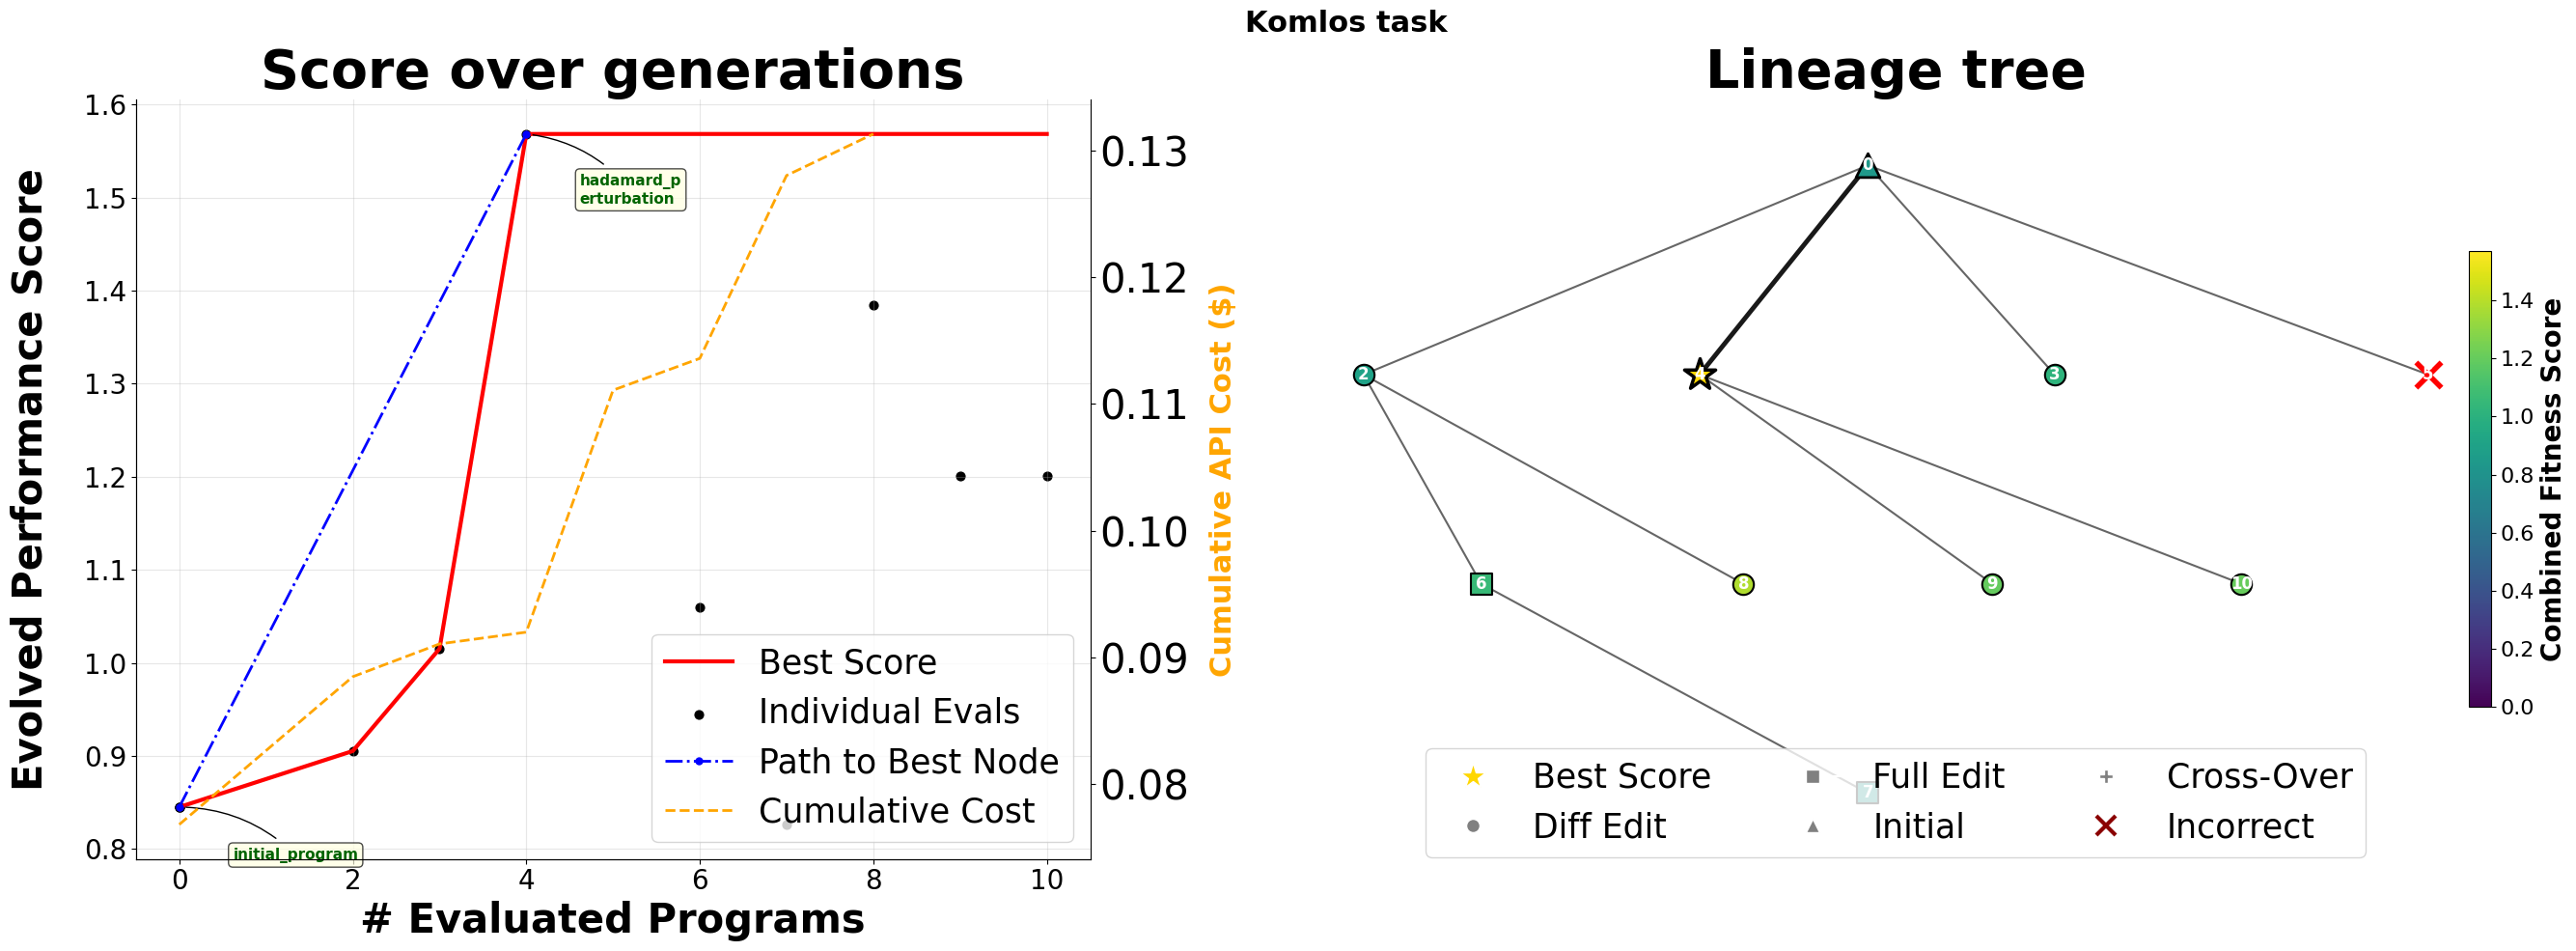

In [5]:
import matplotlib.pyplot as plt

from pathlib import Path

from shinka.utils import load_programs_to_df
from shinka.plots import plot_lineage_tree, plot_evals_performance

warnings.filterwarnings("ignore", category=UserWarning)

results_root = Path("results") / experiment_name

# The db may sit directly in results_root or one level up (shinka convention)
db_candidates = [
    results_root / "programs.sqlite"
    # results_root / results_root / "evolution_db.sqlite",
    # Path("evolution_db.sqlite"),
]

db_path = next((p for p in db_candidates if p.exists()), None)

assert db_path is not None, "Could not find evolution_db.sqlite"

df = load_programs_to_df(str(db_path))

print(f"> Loaded {len(df)} programs from database.")

fig, axs = plt.subplots(1, 2, figsize=(28, 10), gridspec_kw={"width_ratios": [1, 1.5]})
fig.suptitle("Komlos task", fontsize=22, weight="bold")

plot_evals_performance(df, "Score over generations", fig, axs[0])
plot_lineage_tree(df, "Lineage tree", fig, axs[1])

plt.tight_layout()
plt.show()

Load and inspect the best solution

In [6]:
import importlib.util
import numpy as np

best_program = results_root / "best" / "main.py"
assert best_program.exists(), f"Best program not found at {best_program}"

spec = importlib.util.spec_from_file_location("best_program", best_program)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

vectors, cost, signs = mod.run_komlos(n=9)
print(f"Matrix shape  : {vectors.shape}")
print(f"Min discrepancy (best): {cost:.6f}")
print(f"Best signs    : {signs.tolist()}")
print(f"Column norms  : min={np.linalg.norm(vectors, axis=0).min():.6f}, max={np.linalg.norm(vectors, axis=0).max():.6f}")

Matrix shape  : (9, 9)
Min discrepancy (best): 1.553387
Best signs    : [-1, -1, 1, -1, 1, -1, 1, 1, 1]
Column norms  : min=1.000000, max=1.000000
